In [28]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [29]:
class DiscountState(TypedDict):
    total: float
    discount_rate: float
    final_price: float

In [30]:
def apply_discount(state: DiscountState) :
    total = state['total']
    rate = state['discount_rate']
    final = total * (1 - rate)
    return {'final_price': final}

In [31]:
def check_eligibility(state: DiscountState) :
    total = state['total']
    
    if total > 1000:
        return {'discount_rate':0.20}
    elif total > 500:
        return {'discount_rate':0.10}
    else:
        return {'discount_rate':0.0}
        

In [32]:
def no_discount(state: DiscountState) :
    return {'final_price': state['total']}

In [33]:
def router_discount(state: DiscountState) -> str:
    if state['discount_rate'] > 0:
        return 'discount'
    else:
        return 'no_discount'
    

In [ ]:
graph = StateGraph(DiscountState)

graph.add_node("check_eligibility",check_eligibility)

graph.add_node("apply",apply_discount)

graph.add_node("discount",no_discount)


graph.add_edge( START,"check_eligibility" )

graph.add_conditional_edges("check_eligibility",router_discount, {
    "discount":"apply",
    "no_discount":"discount",
})

graph.add_edge("apply", END)

graph.add_edge("discount", END)


In [35]:
workflow = graph.compile()

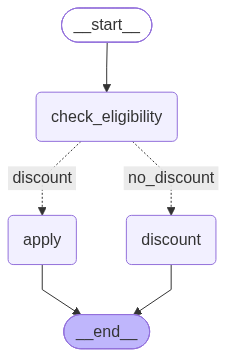

In [36]:
workflow

In [37]:
response = workflow.invoke({'total': 600.0})

In [38]:
print(response)

{'total': 600.0, 'discount_rate': 0.1, 'final_price': 540.0}
